<a href="https://colab.research.google.com/github/vikash000x/AutoEnocoder_VAE/blob/main/VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [59]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [60]:
BATCH_SIZE = 128

data_transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.FashionMNIST(root = "./data",  train= True, transform = data_transform, download = True)
train_loader = DataLoader(dataset = train_dataset, batch_size=BATCH_SIZE, shuffle = True)



100%|██████████| 26.4M/26.4M [00:01<00:00, 19.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 308kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.04MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.9MB/s]


In [61]:
latent_dim = 64

class VAE(nn.Module):
  def __init__(self, input_dim = 784, hidden_dim = 256, latent_dim = latent_dim):
    super().__init__()

    self.fc1 = nn.Linear(input_dim, hidden_dim)
    self.fc_mu = nn.Linear(hidden_dim, latent_dim)
    self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    self.fc2 = nn.Linear(latent_dim, hidden_dim)
    self.fc3 = nn.Linear(hidden_dim, input_dim)

    self.relu = nn.ReLU()
    self.sigmoid = nn.Sigmoid()

  def encoder(self, x):
    h = self.relu(self.fc1(x))
    mu = self.fc_mu(h)
    logvar = self.fc_logvar(h)
    return mu, logvar

  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5*logvar)
    eps = torch.randn_like(std)
    z = mu + eps*std
    return z

  def decoder(self, z):
    h = self.relu(self.fc2(z))
    out = self.sigmoid(self.fc3(h))
    return out

  def forward(self, x):
    mu, logvar = self.encoder(x)
    z = self.reparameterize(mu, logvar)
    x_reconstructed = self.decoder(z)
    return x_reconstructed, mu, logvar






loss calculation

In [62]:
def vae_loss(recon_x, x, mu, logvar):
 # recon_loss = nn.functional.mse_loss(recon_x, x)
  recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction="sum")

  # Corrected KL divergence term: 'mu.pow(2) + logvar.exp()' instead of 'mu.pow(2) * logvar.exp()'
  kl_loss = 0.5*torch.sum(mu.pow(2) + logvar.exp() - logvar -1)

  return recon_loss + kl_loss

In [63]:
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr = 1e-3)

In [65]:
epochs = 15

model.train()

for epoch in range(epochs):
  total_loss = 0

  for x, _ in (train_loader):
    x = x.view(-1, 784).to(device)

    optimizer.zero_grad()

    x_recon, mu, logvar = model(x)
    loss = vae_loss(x_recon, x, mu, logvar) # Removed .mean() as vae_loss already returns a scalar
    loss.backward()
    optimizer.step()

    total_loss = total_loss + loss.item()

  avg_loss = total_loss / len(train_loader.dataset)

  print(f"Epoch [{epoch+1}/{epochs}], loss : {avg_loss:.4f}")

Epoch [1/15], loss : 268.9406
Epoch [2/15], loss : 258.3564
Epoch [3/15], loss : 252.6674
Epoch [4/15], loss : 249.5765
Epoch [5/15], loss : 247.7099
Epoch [6/15], loss : 246.4995
Epoch [7/15], loss : 245.5762
Epoch [8/15], loss : 244.8586
Epoch [9/15], loss : 244.2505
Epoch [10/15], loss : 243.8101
Epoch [11/15], loss : 243.4008
Epoch [12/15], loss : 243.0396
Epoch [13/15], loss : 242.7919
Epoch [14/15], loss : 242.5482
Epoch [15/15], loss : 242.3174


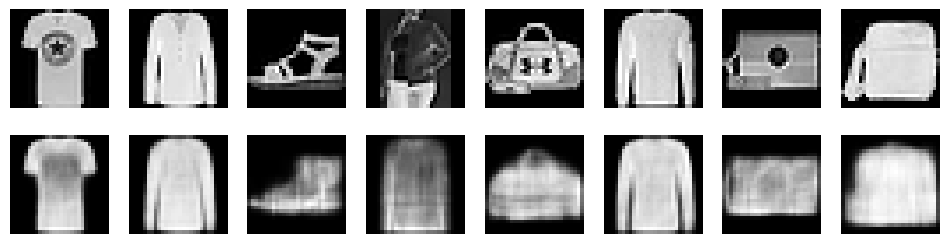

In [66]:
model.eval()

with torch.no_grad():
  x, _  = next(iter(train_loader))
  x = x.view(-1, 784).to(device)

  x = x.cpu()
  x_recon , _, _ = model(x)

  n = 8
  plt.figure(figsize= (12, 3))
  for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(x[i].view(28, 28).numpy(), cmap = "gray")
    plt.axis("off")

    plt.subplot(2, n, i+1+n)
    plt.imshow(x_recon[i].view(28, 28).numpy(), cmap = "gray")
    plt.axis("off")

  plt.show()


rando vector operation

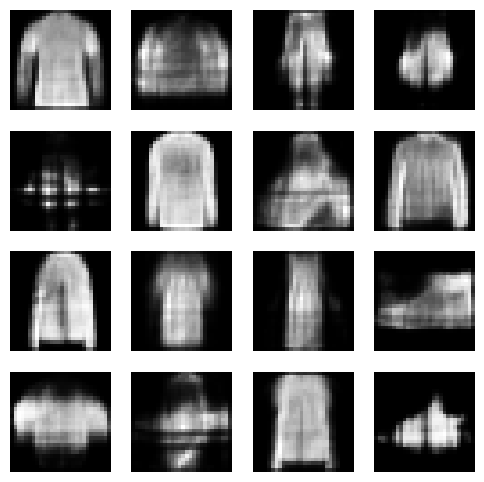

In [67]:
with torch.no_grad():
  z = torch.randn(16, latent_dim).to(device)
  samples = model.decoder(z).cpu()

  plt.figure(figsize = (6, 6))
  for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(samples[i].view(28, 28).numpy(), cmap = "gray")
    plt.axis("off")

  plt.show()